In [1]:
pip install ioh


[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Running F1...


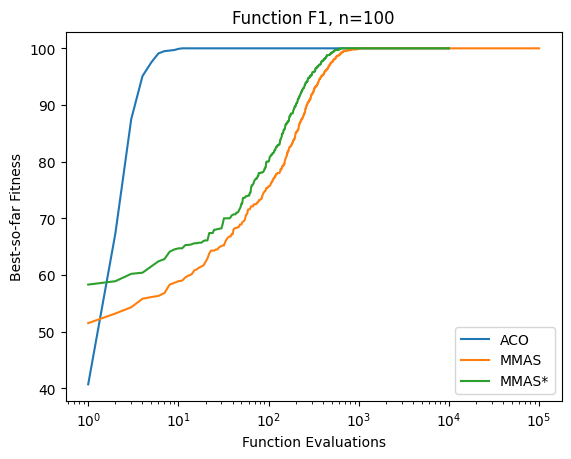

Running F2...


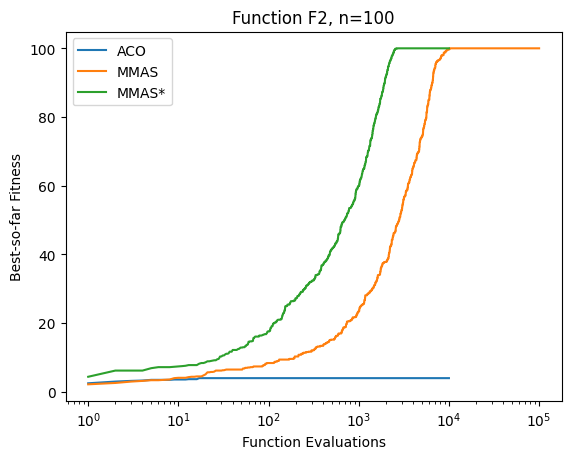

Running F3...


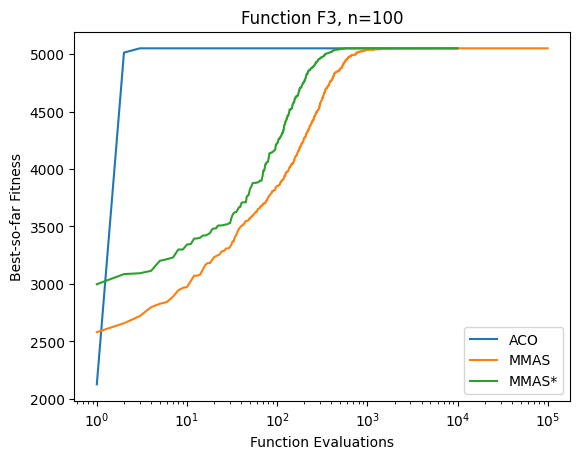

Running F18...


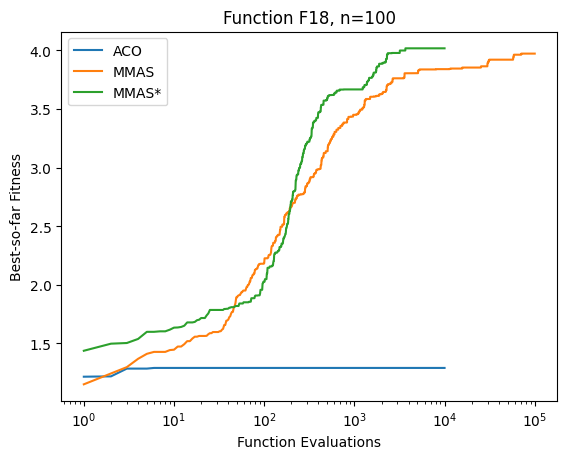

Running F23...


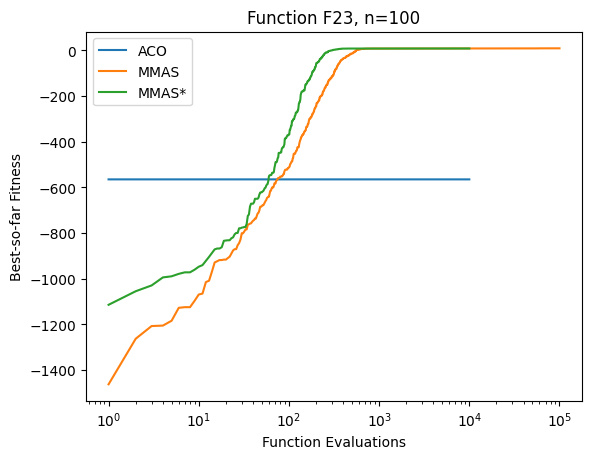

Running F24...


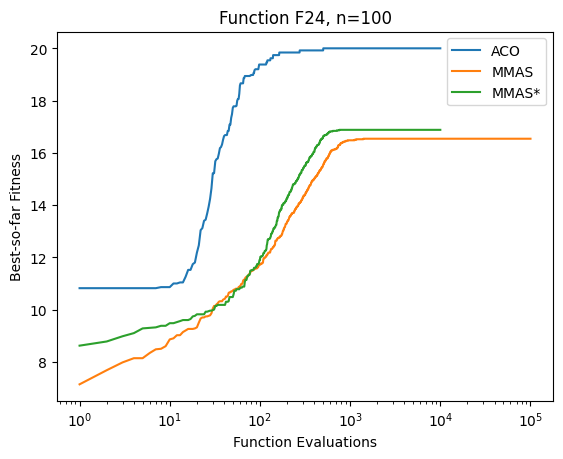

Running F25...


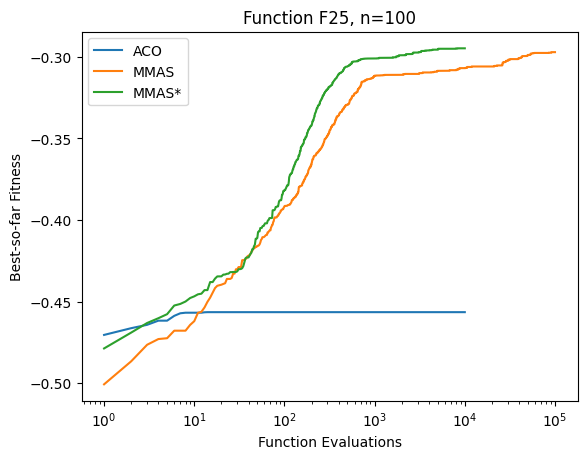

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import ioh
from ACO import ACO
from mmas import mmas, resolve_rho
from mmas_star import MMASStar, MMASStarConfig

#config
DIM = 100
BUDGET = 100000
RUNS = 10
FUNCTIONS = [1, 2, 3, 18, 23, 24, 25]

def run_aco(problem, budget, runs=10):
    curves = []
    for r in range(runs):
        aco = ACO(n=DIM, num_ants=10, max_iter=budget // 10)
        _, _, curve = aco.run(problem)
        curves.append(curve)
    return np.mean(curves, axis=0)

def run_mmas(problem, budget, runs=10):
    curves = []
    for r in range(runs):
        rng = np.random.default_rng(r)
        f_star, curve = mmas(problem, budget, resolve_rho("1/sqrt(n)", DIM), rng)
        curves.append(curve)
    return np.mean(curves, axis=0)

def run_mmas_star(problem, budget, runs=10):
    curves = []
    for r in range(runs):
        cfg = MMASStarConfig(n=DIM, num_ants=10, rho=0.02, seed=r)
        alg = MMASStar(cfg)
        best_f, curve = alg.run(budget, problem)
        curves.append(curve)
    return np.mean([np.array(c) for c in curves], axis=0)



for fid in FUNCTIONS:
    problem = ioh.get_problem(fid, dimension=DIM, instance=1,
                              problem_class=ioh.ProblemClass.PBO)
    print(f"Running F{fid}...")

    aco_curve = run_aco(problem, BUDGET, RUNS)
    mmas_curve = run_mmas(problem, BUDGET, RUNS)
    mmas_star_curve = run_mmas_star(problem, BUDGET, RUNS)

    plt.figure()

    x_aco = np.arange(1, len(aco_curve) + 1)
    x_mmas = np.arange(1, len(mmas_curve) + 1)
    x_mmas_star = np.arange(1, len(mmas_star_curve) + 1)

    plt.plot(x_aco, aco_curve, label="ACO")
    plt.plot(x_mmas, mmas_curve, label="MMAS")
    plt.plot(x_mmas_star, mmas_star_curve, label="MMAS*")

    plt.xscale("log")
    plt.xlabel("Function Evaluations")
    plt.ylabel("Best-so-far Fitness")
    plt.title(f"Function F{fid}, n={DIM}")
    plt.legend()
    plt.show()

# Analysis


The ACO algorithm seems to have certain advantages in rapid convergence only in simple functions like F1 and F3, but it almost completely fails in other more complex or deceptive functions. So ACO is only suitable for handling simple problems. The algorithms of MMAS and MMAS* are much better. They can find relatively good results or even optimal solutions in all functions, and at the same time have excellent robustness. Among them, the early performance and convergence speed of MMAS* are even faster than those of MMAS. Overall, MMAS* is the most outstanding algorithm, followed by MMAS, while ACO performs relatively poorly.